In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.linalg import sqrtm

Original Matrix:
 tensor([[[[1., 0., 1., 0., 1.],
          [0., 1., 0., 1., 0.],
          [1., 0., 1., 0., 1.],
          [0., 1., 0., 1., 0.],
          [1., 0., 1., 0., 1.]]]])


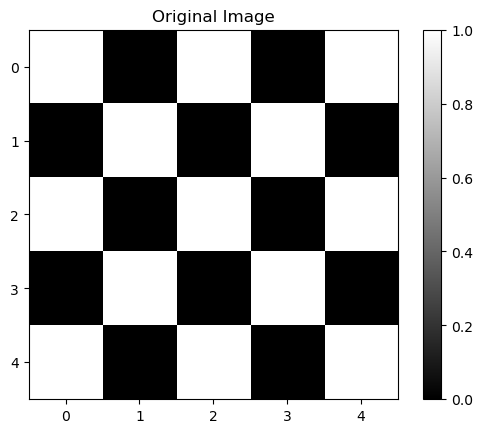

In [2]:
x0 = torch.zeros((1,1,5,5))

# chess pattern
for i in range(5):
    for j in range(5):
        if (i + j) % 2 == 0:
            x0[0,0,i,j] = 1.0

print("Original Matrix:\n", x0)

plt.imshow(x0[0,0].numpy(), cmap='gray')
plt.title("Original Image")
plt.colorbar()
plt.show()

In [3]:
T = 10
betas = torch.linspace(0.0001, 0.02, T)
alphas = 1 - betas
alpha_hat = torch.cumprod(alphas, dim=0)

In [4]:
def forward_diffusion(x0, t):
    t = int(t)
    noise = torch.randn_like(x0)

    x_t = torch.sqrt(alpha_hat[t]) * x0 + \
          torch.sqrt(1 - alpha_hat[t]) * noise

    return x_t, noise

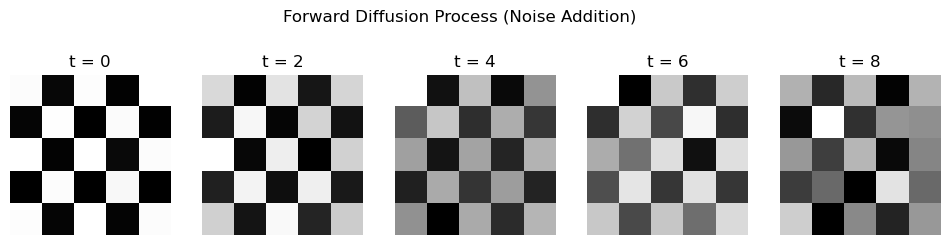

In [5]:
plt.figure(figsize=(12,3))

num_steps_to_show = 5
step_gap = T // num_steps_to_show

for i in range(num_steps_to_show):
    t = torch.tensor([i * step_gap])

    x_t, _ = forward_diffusion(x0, t)

    plt.subplot(1, num_steps_to_show, i+1)
    plt.imshow(x_t[0,0].detach().numpy(), cmap='gray')
    plt.title(f"t = {int(t.item())}")
    plt.axis('off')

plt.suptitle("Forward Diffusion Process (Noise Addition)")
plt.show()

In [6]:
def reverse_step(x_t, t, pred_noise):
    t = t.item()   # convert tensor → int

    alpha_t = alphas[t]        # ✅ FIX
    alpha_hat_t = alpha_hat[t]
    beta_t = betas[t]          # ✅ FIX

    # reshape
    alpha_t = alpha_t.view(-1, 1, 1, 1)
    alpha_hat_t = alpha_hat_t.view(-1, 1, 1, 1)
    beta_t = beta_t.view(-1, 1, 1, 1)

    mean = (1 / torch.sqrt(alpha_t)) * (
        x_t - ((1 - alpha_t) / torch.sqrt(1 - alpha_hat_t)) * pred_noise
    )

    if t > 0:
        noise = torch.randn_like(x_t)
        sigma = torch.sqrt(beta_t)
        x_prev = mean + sigma * noise
    else:
        x_prev = mean

    return x_prev

In [7]:
import torch
import torch.nn as nn
import math

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2

        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)

        emb = t[:, None] * emb[None, :]

        emb = torch.cat((torch.sin(emb), torch.cos(emb)), dim=1)

        return emb

In [8]:
class SimpleDenoiser(nn.Module):
    def __init__(self):
        super().__init__()

        self.time_embed = SinusoidalTimeEmbedding(32)

        self.net = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(16,16,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(16,1,3,padding=1)
        )

        self.fc = nn.Linear(32, 25)

    def forward(self, x, t):
        t_emb = self.time_embed(t)
        t_emb = self.fc(t_emb)
        t_emb = t_emb.view(-1,1,5,5)

        x = x + t_emb

        return self.net(x)

In [9]:
model = SimpleDenoiser()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [10]:
def reconstruct(x_t, pred_noise, t):
    t = int(t)
    return (1 / torch.sqrt(alpha_hat[t])) * \
           (x_t - torch.sqrt(1 - alpha_hat[t]) * pred_noise)

In [11]:
def compute_psnr(x, y):
    mse = F.mse_loss(x, y)
    return 10 * torch.log10(1 / mse)

In [12]:
def compute_ssim(x, y):
    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    mu_x = torch.mean(x)
    mu_y = torch.mean(y)

    sigma_x = torch.var(x)
    sigma_y = torch.var(y)
    sigma_xy = torch.mean((x - mu_x) * (y - mu_y))

    ssim = ((2 * mu_x * mu_y + C1) * (2 * sigma_xy + C2)) / \
           ((mu_x**2 + mu_y**2 + C1) * (sigma_x + sigma_y + C2))

    return ssim

In [13]:
losses = []
psnr_list = []
ssim_list = []

EPOCHS = 300

for epoch in range(EPOCHS):
    t = torch.randint(0, T, (1,))
    
    x_t, true_noise = forward_diffusion(x0, t)
    pred_noise = model(x_t, t)

    loss = F.mse_loss(pred_noise, true_noise)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    # ---- Reconstruction ----
    x_recon = reconstruct(x_t, pred_noise, t)

    psnr_val = compute_psnr(x0, x_recon).item()
    ssim_val = compute_ssim(x0, x_recon).item()

    psnr_list.append(psnr_val)
    ssim_list.append(ssim_val)

    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f} | PSNR: {psnr_val:.2f} | SSIM: {ssim_val:.4f}")

Epoch 0 | Loss: 0.8300 | PSNR: 10.54 | SSIM: 0.8357
Epoch 50 | Loss: 1.1091 | PSNR: 12.69 | SSIM: 0.8684
Epoch 100 | Loss: 0.8563 | PSNR: 17.07 | SSIM: 0.9222
Epoch 150 | Loss: 0.8361 | PSNR: 15.40 | SSIM: 0.9064
Epoch 200 | Loss: 0.9331 | PSNR: 26.47 | SSIM: 0.9557
Epoch 250 | Loss: 0.5120 | PSNR: 21.51 | SSIM: 0.9455


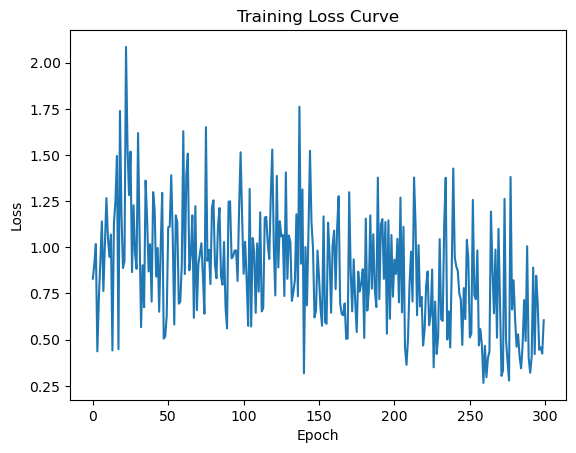

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

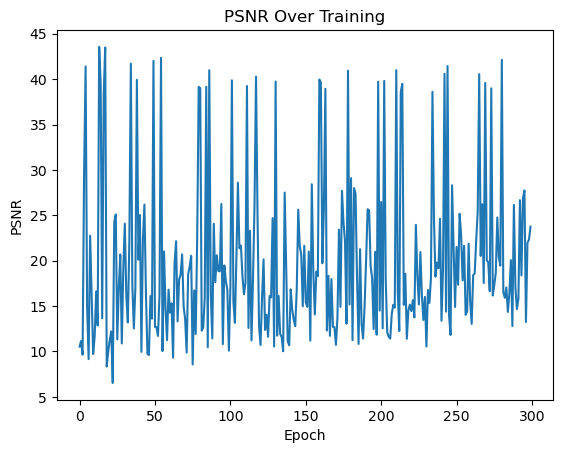

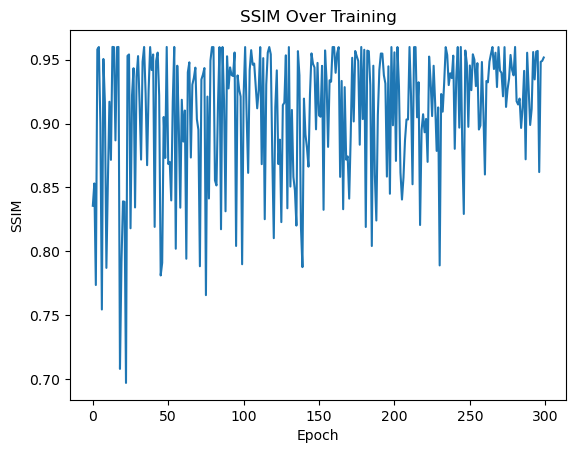

In [15]:
plt.figure()
plt.plot(psnr_list)
plt.title("PSNR Over Training")
plt.xlabel("Epoch")
plt.ylabel("PSNR")
plt.show()

plt.figure()
plt.plot(ssim_list)
plt.title("SSIM Over Training")
plt.xlabel("Epoch")
plt.ylabel("SSIM")
plt.show()

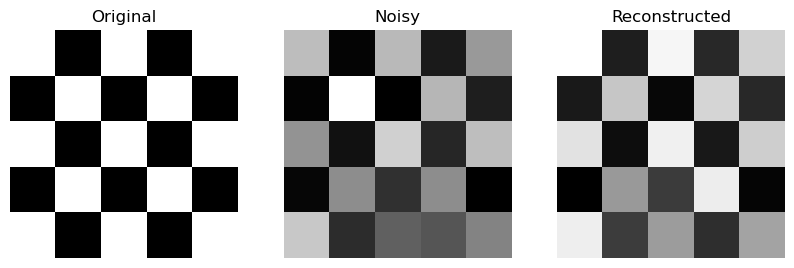

In [16]:
t_test = torch.tensor([T-1])

x_t, _ = forward_diffusion(x0, t_test)

with torch.no_grad():
    pred_noise = model(x_t, t_test)

x_recon = reconstruct(x_t, pred_noise, t_test)

orig = x0.squeeze().numpy()
noisy = x_t.squeeze().numpy()
recon = x_recon.squeeze().numpy()

fig, axs = plt.subplots(1, 3, figsize=(10,3))

axs[0].imshow(orig, cmap='gray')
axs[0].set_title("Original")

axs[1].imshow(noisy, cmap='gray')
axs[1].set_title("Noisy")

axs[2].imshow(recon, cmap='gray')
axs[2].set_title("Reconstructed")

for ax in axs:
    ax.axis('off')

plt.show()

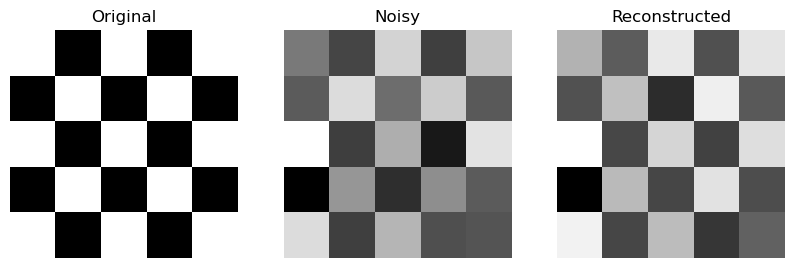

In [17]:
t_test = torch.tensor([T-1])

x_t, _ = forward_diffusion(x0, t_test)

with torch.no_grad():
    pred_noise = model(x_t, t_test)

x_recon = reconstruct(x_t, pred_noise, t_test)

orig = x0.squeeze().numpy()
noisy = x_t.squeeze().numpy()
recon = x_recon.squeeze().numpy()

fig, axs = plt.subplots(1, 3, figsize=(10,3))

axs[0].imshow(orig, cmap='gray')
axs[0].set_title("Original")

axs[1].imshow(noisy, cmap='gray')
axs[1].set_title("Noisy")

axs[2].imshow(recon, cmap='gray')
axs[2].set_title("Reconstructed")

for ax in axs:
    ax.axis('off')

plt.show()

In [18]:
baseline_psnr = compute_psnr(x0, x_t).item()
model_psnr = compute_psnr(x0, x_recon).item()

baseline_ssim = compute_ssim(x0, x_t).item()
model_ssim = compute_ssim(x0, x_recon).item()

print("---- Comparison ----")
print(f"Baseline PSNR: {baseline_psnr:.2f}")
print(f"Model PSNR:    {model_psnr:.2f}")

print(f"Baseline SSIM: {baseline_ssim:.4f}")
print(f"Model SSIM:    {model_ssim:.4f}")

---- Comparison ----
Baseline PSNR: 9.51
Model PSNR:    12.83
Baseline SSIM: 0.7822
Model SSIM:    0.8669


In [19]:
import pandas as pd

results = pd.DataFrame({
    "Metric": ["PSNR", "SSIM"],
    "Baseline": [baseline_psnr, baseline_ssim],
    "Model": [model_psnr, model_ssim]
})

results

,Metric,Baseline,Model
0,PSNR,9.511861,12.826315
1,SSIM,0.782167,0.866918


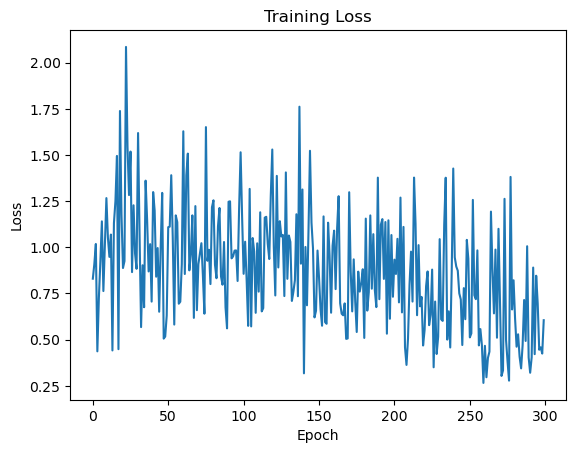

In [20]:
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [21]:
t = torch.tensor([5])

x_t, true_noise = forward_diffusion(x0, t)
pred_noise = model(x_t, t)

x_recon = reconstruct(x_t, pred_noise, t)

print("\nReconstructed Matrix:\n", x_recon)


Reconstructed Matrix:
 tensor([[[[ 0.9929,  0.1609,  0.7600, -0.1449,  1.1022],
          [ 0.2244,  0.8144,  0.0039,  0.9144,  0.0189],
          [ 0.7822, -0.0187,  0.9930,  0.0561,  0.9028],
          [ 0.0474,  0.8303,  0.0143,  1.1526, -0.2423],
          [ 0.8600,  0.3879,  0.9837,  0.0854,  0.8934]]]],
       grad_fn=<MulBackward0>)


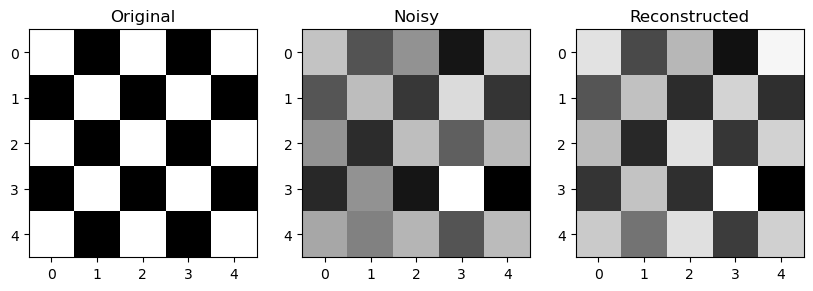

In [22]:
plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.imshow(x0[0,0].detach().numpy(), cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(x_t[0,0].detach().numpy(), cmap='gray')
plt.title("Noisy")

plt.subplot(1,3,3)
plt.imshow(x_recon[0,0].detach().numpy(), cmap='gray')
plt.title("Reconstructed")

plt.show()

In [23]:
psnr_value = compute_psnr(x0, x_recon)
ssim_value = compute_ssim(x0, x_recon)

print("PSNR:", psnr_value.item())
print("SSIM:", ssim_value.item())

PSNR: 16.419269561767578
SSIM: 0.9124541282653809


In [24]:
def get_features(x):
    return x.view(x.size(0), -1)

In [25]:
def sample(model, shape=(1,1,5,5)):
    model.eval()

    x = torch.randn(shape)  # start from noise
    steps = []

    for t in reversed(range(T)):
        t_tensor = torch.tensor([t])

        with torch.no_grad():
            pred_noise = model(x, t_tensor)

        x = reverse_step(x, t_tensor, pred_noise)

        steps.append(x.detach().clone())

    return x, steps

In [26]:
generated, steps = sample(model)

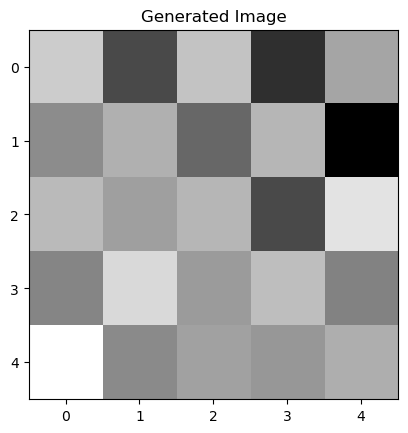

In [27]:
plt.imshow(generated[0,0].detach().numpy(), cmap='gray')
plt.title("Generated Image")
plt.show()

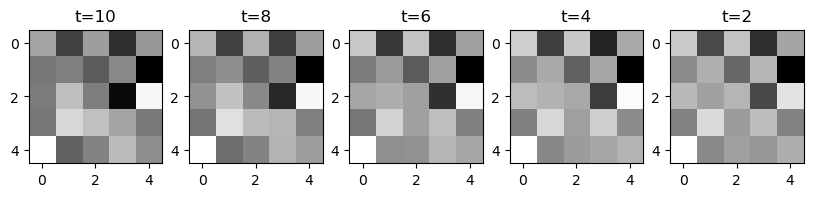

In [28]:
plt.figure(figsize=(10,3))

for i in range(5):
    idx = i * 2
    plt.subplot(1,5,i+1)
    plt.imshow(steps[idx][0,0].detach().numpy(), cmap='gray')
    plt.title(f"t={T-idx}")

plt.show()